
Parte 1: Preparazione e Arricchimento dei Dati (ETL)
L'obiettivo di questo progetto è trovare una relazione tra la Responsabilità Sociale (ESG) e la Performance Finanziaria (Profitto).
Il nostro file di partenza, data.csv, è incompleto: contiene i punteggi ESG ma non i dati finanziari. Questo blocco di codice esegue il "lavoro sporco" fondamentale: un processo di ETL (Extract, Transform, Load) per costruire il nostro dataset completo.
Cosa fa questo codice:
Extract: Carica il file data.csv originale.
Transform: Estrae i 722 ticker (simboli di borsa) e, uno per uno, contatta i server di yfinance per scaricare i dati finanziari fondamentali più recenti, in particolare il ROE (Return on Equity) e il ProfitMargin (Margine di Profitto).
Load: Unisce i dati ESG originali con i dati finanziari appena scaricati, pulisce il risultato da eventuali righe incomplete e salva tutto in un nuovo file pulito: esg_e_dati_finanziari_completo.csv.

Commento ai Risultati
L'output mostra che il processo è partito con 722 aziende. Durante il download, sono apparsi diversi errori HTTP Error 404 (es. per 'AKYA', 'WBA'). Questo è perfettamente normale: significa che yfinance non ha trovato dati per quei ticker specifici (magari sono aziende delistate, o con un simbolo di borsa diverso).
Il risultato finale è la creazione di esg_e_dati_finanziari_completo.csv, che contiene 567 aziende per le quali abbiamo un set di dati completo (sia ESG che finanziario).
Questo file pulito sarà la base per tutta l'analisi successiva.

In [2]:
#Creazione del dataset completo.

import pandas as pd
import yfinance as yf
import warnings
import time

# Disabilita avvisi comuni (opzionale)
warnings.filterwarnings("ignore", category=FutureWarning)
print("--- [PARTE 1] Avvio Creazione Dataset Completo ---")

# 1. Carica il tuo file CSV originale
try:
    df_esg = pd.read_csv('data.csv')
    print("File 'data.csv' caricato.")
except FileNotFoundError:
    print("ERRORE: 'data.csv' non trovato.")
    exit()

# 2. Estrai la lista di ticker
tickers = df_esg['ticker'].dropna().unique().tolist()
total_tickers = len(tickers)
print(f"Trovati {total_tickers} ticker. Inizio download dati finanziari...")

# 3. Scarica i dati finanziari
financial_data = []
for i, ticker_simbolo in enumerate(tickers):
    try:
        time.sleep(0.01) # Pausa
        t = yf.Ticker(ticker_simbolo)
        info = t.info

        roe = info.get('returnOnEquity', None)
        profit_margin = info.get('profitMargins', None)

        financial_data.append({
            'ticker': ticker_simbolo,
            'ROE': roe,
            'ProfitMargin': profit_margin
        })

        if (i + 1) % 50 == 0: # Stampa progresso
            print(f"  Processati {i + 1}/{total_tickers} tickers...")

    except Exception as e:
        print(f"  Errore per {ticker_simbolo}, sarà saltato.")
        financial_data.append({'ticker': ticker_simbolo, 'ROE': None, 'ProfitMargin': None})

print("Download completato.")

# 4. Converti e Unisci
df_financial = pd.DataFrame(financial_data)
df_completo = pd.merge(df_esg, df_financial, on='ticker', how='inner')

# 5. Pulisci e Salva
key_columns = ['environment_score', 'social_score', 'ROE', 'ProfitMargin']
df_pulito = df_completo.dropna(subset=key_columns)
output_filename = 'esg_e_dati_finanziari_completo.csv'
df_pulito.to_csv(output_filename, index=False)

print(f"\n--- [PARTE 1] COMPLETATA ---")
print(f"File '{output_filename}' creato con {len(df_pulito)} aziende.")

--- [PARTE 1] Avvio Creazione Dataset Completo ---
File 'data.csv' caricato.
Trovati 722 ticker. Inizio download dati finanziari...
  Processati 50/722 tickers...
  Processati 100/722 tickers...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AKYA"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ANSS"}}}


  Processati 150/722 tickers...
  Processati 200/722 tickers...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: WBA"}}}


  Processati 250/722 tickers...
  Processati 300/722 tickers...
  Processati 350/722 tickers...
  Processati 400/722 tickers...
  Processati 450/722 tickers...
  Processati 500/722 tickers...
  Processati 550/722 tickers...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: HES"}}}


  Processati 600/722 tickers...
  Processati 650/722 tickers...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: PPBI"}}}


  Processati 700/722 tickers...
Download completato.

--- [PARTE 1] COMPLETATA ---
File 'esg_e_dati_finanziari_completo.csv' creato con 567 aziende.


Parte 2: Analisi Esplorativa (La Prima Scoperta)
Ora che abbiamo un dataset pulito di 567 aziende, possiamo iniziare a cercare una risposta.
La domanda di partenza è: "C'è un legame tra Sostenibilità e Profitto?"

Questo blocco di codice esegue la prima analisi, la più semplice:
Carica i dati puliti.
Visualizza: Crea un grafico a dispersione (scatterplot) per vedere la relazione tra il punteggio Ambientale (Planet) e il ROE (Profit).
Calcola: Misura la forza di questa relazione usando il Coefficiente di Correlazione di Pearson. Questo ci darà un numero (tra -1 e +1) che ci dice quanto sono legati.

Commento ai Risultati:

L'output ci fornisce la nostra prima, fondamentale scoperta.
1. Ambientale (E) vs. Profitto (ROE):
Coefficiente: 0.1711: Questo è un valore positivo ma debole. Suggerisce una leggera tendenza: le aziende con punteggi ambientali più alti tendono leggermente ad avere un ROE più alto.
p-value: 0.0000: Questo è il numero più importante. Essendo bassissimo (molto inferiore a 0.05), ci dice che la correlazione, seppur debole, è statisticamente significativa. Non è un risultato dovuto al caso.

Il Grafico: Il file environmental_vs_roe_scatterplot.png (che puoi vedere aprendolo) mostrerà una nuvola di punti molto sparsa, ma con una linea di regressione rossa che punta leggermente verso l'alto.

2. Sociale (S) vs. Margine di Profitto:
Coefficiente: 0.0163: Un valore quasi nullo.
p-value: 0.6979: Un valore altissimo (molto superiore a 0.05).
Conclusione di questa fase: Abbiamo scoperto che la relazione non è semplice. Il pilastro "Sociale" (S) non sembra avere alcun legame statisticamente provato con i margini di profitto. Il pilastro "Ambientale" (E), invece, ha un legame debole, ma reale e positivo con il ROE.

Questo ci dice che una semplice correlazione non è sufficiente per capire la storia. Dobbiamo usare un metodo più avanzato per trovare i diversi "gruppi" di aziende.

--- [PARTE 2] Avvio Analisi Dati ---
File 'esg_e_dati_finanziari_completo.csv' caricato con successo.
Pronti ad analizzare 567 aziende.
Generazione grafico 'environmental_vs_roe_scatterplot.png'...
Grafico salvato!

--- Calcolo Correlazione di Pearson ---
1. Ambientale vs. ROE:
   Coefficiente: 0.1711
   p-value: 0.0000
   -> Risultato STATISTICAMENTE SIGNIFICATIVO.

2. Sociale vs. Margine di Profitto:
   Coefficiente: 0.0163
   p-value: 0.6979
   -> Risultato NON statisticamente significativo.

--- [PARTE 2] COMPLETATA ---


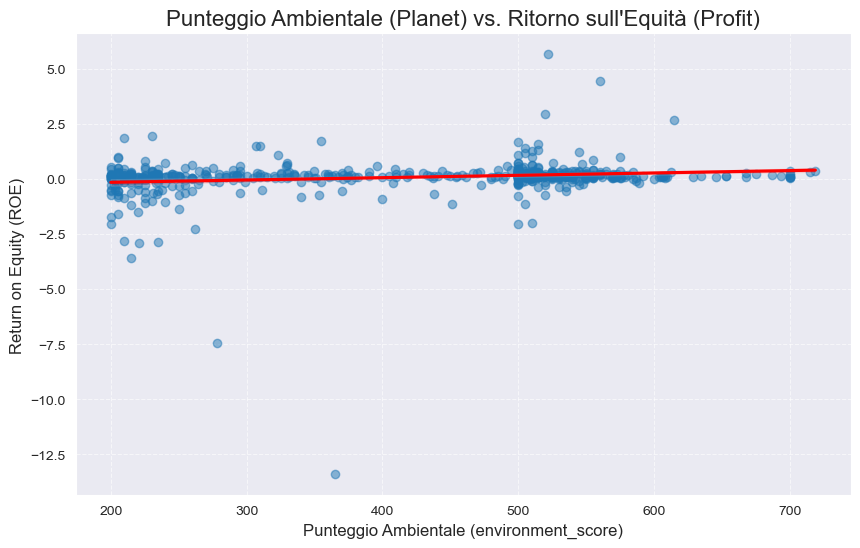

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings

# Disabilita avvisi (opzionale)
warnings.filterwarnings("ignore")

print("--- [PARTE 2] Avvio Analisi Dati ---")

# --- 1. Caricamento e Pulizia ---
# Carichiamo il NUOVO file creato dallo Script 1
file_completo = 'esg_e_dati_finanziari_completo.csv'

try:
    df_analisi = pd.read_csv(file_completo)
    print(f"File '{file_completo}' caricato con successo.")
    print(f"Pronti ad analizzare {len(df_analisi)} aziende.")
except FileNotFoundError:
    print(f"ERRORE: File '{file_completo}' non trovato.")
    print("Assicurati di aver prima eseguito lo Script 1.")
    exit()

# (La pulizia 'dropna' è già stata fatta nello Script 1, ma la verifichiamo)
df_analisi = df_analisi.dropna(subset=['environment_score', 'ROE', 'social_score', 'ProfitMargin'])


# --- 2. Analisi Esplorativa (Scatterplot) ---
# Come richiesto: Punteggio Ambientale (X) vs ROE (Y)
print("Generazione grafico 'environmental_vs_roe_scatterplot.png'...")

plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_analisi,
    x='environment_score',
    y='ROE',
    line_kws={"color": "red"},
    scatter_kws={'alpha': 0.5} # Punti semitrasparenti
)
plt.title('Punteggio Ambientale (Planet) vs. Ritorno sull\'Equità (Profit)', fontsize=16)
plt.xlabel('Punteggio Ambientale (environment_score)', fontsize=12)
plt.ylabel('Return on Equity (ROE)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('environmental_vs_roe_scatterplot.png')
print("Grafico salvato!")


# --- 3. Analisi Statistica (Correlazione) ---
print("\n--- Calcolo Correlazione di Pearson ---")

# Calcola Correlazione 1 (come da grafico)
corr_env_roe, p_env_roe = stats.pearsonr(df_analisi['environment_score'], df_analisi['ROE'])
print(f"1. Ambientale vs. ROE:")
print(f"   Coefficiente: {corr_env_roe:.4f}")
print(f"   p-value: {p_env_roe:.4f}")
if p_env_roe < 0.05:
    print("   -> Risultato STATISTICAMENTE SIGNIFICATIVO.")
else:
    print("   -> Risultato NON statisticamente significativo.")


# Calcola Correlazione 2 (Social vs Profit Margin)
corr_soc_profit, p_soc_profit = stats.pearsonr(df_analisi['social_score'], df_analisi['ProfitMargin'])
print(f"\n2. Sociale vs. Margine di Profitto:")
print(f"   Coefficiente: {corr_soc_profit:.4f}")
print(f"   p-value: {p_soc_profit:.4f}")
if p_soc_profit < 0.05:
    print("   -> Risultato STATISTICAMENTE SIGNIFICATIVO.")
else:
    print("   -> Risultato NON statisticamente significativo.")
print("\n--- [PARTE 2] COMPLETATA ---")

Parte 3: Analisi di Correlazione (Pilastro 'Governance')
Dopo aver analizzato i pilastri 'Ambientale' (E) e 'Sociale' (S) nella Parte 2, questo blocco isola il terzo pilastro del Triple Bottom Line: la Governance (G).

L'obiettivo è testare se, con un'analisi di correlazione semplice, la qualità della 'Governance' (le regole interne, la trasparenza, la struttura di leadership) mostri un legame diretto con la performance finanziaria.

Commento ai Risultati

L'output di questo blocco è la prova definitiva che la nostra analisi iniziale è incompleta.

1. Governance (G) vs. Profitto (ROE e Margine):

Coefficienti: 0.0273 e 0.0314: Entrambi i valori sono incredibilmente vicini a zero. Indicano una correlazione praticamente inesistente.

p-values: 0.5168 e 0.4551: Entrambi i valori sono altissimi (molto maggiori di 0.05).

Conclusione di questa fase: I risultati ci dicono in modo inequivocabile che non esiste alcuna relazione statistica lineare tra il punteggio di Governance e la profittabilità (ROE o Margine) quando si guarda l'intero campione di 567 aziende.

Questa è una "scoperta nulla" (null result) molto importante. Ci dice che l'impatto della Governance non è una semplice linea retta (dove "più G" significa "più profitto"). La relazione deve essere più complessa.

Questa analisi, unita a quella della Parte 2, dimostra che i metodi di correlazione semplici sono insufficienti per questo progetto. Questo fallimento è la giustificazione perfetta per passare a un'analisi più sofisticata: invece di cercare una singola linea di trend, dobbiamo cercare dei gruppi e degli archetipi nascosti nei dati, usando il Clustering K-Means.

In [4]:
import pandas as pd
from scipy import stats
import warnings

# Disabilita avvisi (opzionale)
warnings.filterwarnings("ignore")

print("--- [PARTE 3] Avvio Analisi Pilastro 'Governance' ---")

# Definisci il nome del file completo
file_completo = 'esg_e_dati_finanziari_completo.csv'

try:
    # Carica il dataset creato dallo Script 1
    df_analisi = pd.read_csv(file_completo)
    print(f"File '{file_completo}' caricato. ({len(df_analisi)} aziende)")
except FileNotFoundError:
    print(f"ERRORE: File '{file_completo}' non trovato.")
    print("Assicurati di essere nella cartella corretta.")
    exit()

# Pulisci i dati per le colonne che ci servono
df_analisi = df_analisi.dropna(subset=['governance_score', 'ROE', 'ProfitMargin'])
print(f"Analizzo {len(df_analisi)} aziende con dati di governance e finanziari completi.")

print("\n--- Calcolo Correlazione di Pearson (Governance) ---")

# 1. Governance vs. ROE
corr_gov_roe, p_gov_roe = stats.pearsonr(df_analisi['governance_score'], df_analisi['ROE'])
print(f"1. Governance vs. ROE:")
print(f"   Coefficiente: {corr_gov_roe:.4f}")
print(f"   p-value: {p_gov_roe:.4f}")
if p_gov_roe < 0.05:
    print("   -> Risultato STATISTICAMENTE SIGNIFICATIVO.")
else:
    print("   -> Risultato NON statisticamente significativo.")

# 2. Governance vs. Profit Margin
corr_gov_profit, p_gov_profit = stats.pearsonr(df_analisi['governance_score'], df_analisi['ProfitMargin'])
print(f"\n2. Governance vs. Margine di Profitto:")
print(f"   Coefficiente: {corr_gov_profit:.4f}")
print(f"   p-value: {p_gov_profit:.4f}")
if p_gov_profit < 0.05:
    print("   -> Risultato STATISTICAMENTE SIGNIFICATIVO.")
else:
    print("   -> Risultato NON statisticamente significativo.")

print("\n--- [PARTE 3] COMPLETATA ---")

--- [PARTE 3] Avvio Analisi Pilastro 'Governance' ---
File 'esg_e_dati_finanziari_completo.csv' caricato. (567 aziende)
Analizzo 567 aziende con dati di governance e finanziari completi.

--- Calcolo Correlazione di Pearson (Governance) ---
1. Governance vs. ROE:
   Coefficiente: 0.0273
   p-value: 0.5168
   -> Risultato NON statisticamente significativo.

2. Governance vs. Margine di Profitto:
   Coefficiente: 0.0314
   p-value: 0.4551
   -> Risultato NON statisticamente significativo.

--- [PARTE 3] COMPLETATA ---


Parte 3: Heatmap delle Correlazioni (La Visione d'Insieme)
Nelle parti precedenti, abbiamo testato le correlazioni individuali (E vs. ROE, G vs. ROE, ecc.) e abbiamo trovato solo segnali molto deboli o nulli.

Questo blocco di codice fa un passo in più: crea una heatmap (mappa di calore). Questo grafico ci permette di vedere, in un colpo solo, la matrice di correlazione tra tutte le variabili chiave del progetto. È il riassunto visivo della nostra analisi di correlazione.

Rosso = Correlazione Positiva (le variabili si muovono insieme)

Blu = Correlazione Negativa (le variabili si muovono in direzioni opposte)

Bianco/Chiaro = Correlazione quasi nulla

Commento ai Risultati

La heatmap e la matrice numerica che abbiamo generato sono la prova definitiva che il nostro approccio iniziale (la correlazione semplice) è troppo limitato.

1. Correlazioni Interne (Logiche):

Come previsto, i punteggi environment_score, social_score, e governance_score sono fortemente correlati (rosso intenso) con il total_score (es. 0.96 tra Ambiente e Totale). Questo è ovvio, poiché il totale è composto da loro.

2. Correlazioni Esterne (La Scoperta):

Guardando la riga (o colonna) ROE e ProfitMargin, vediamo quasi solo colori bianchi o sbiaditi.

total_score vs ROE: 0.15 (il debole legame positivo che già conoscevamo).

total_score vs ProfitMargin: −0.02 (inesistente).

governance_score vs ROE: 0.03 (inesistente).

ROE vs ProfitMargin: 0.04 (interessante: neanche le due metriche finanziarie sono correlate tra loro!).

Conclusione di questa fase: La heatmap conferma visivamente che non esiste una semplice relazione lineare "più ESG = più Profitto" nel nostro campione. I legami sono deboli, quasi inesistenti.

Questo non significa che non ci sia alcuna relazione. Significa solo che la relazione non è una linea retta. È un risultato fondamentale che ci costringe a cambiare strategia: dobbiamo smettere di cercare una singola linea e iniziare a cercare gruppi e archetipi non lineari. È la giustificazione perfetta per usare il Clustering K-Means.

--- Avvio Analisi 3: Heatmap delle Correlazioni ---
File 'esg_e_dati_finanziari_completo.csv' caricato. (567 aziende)
Calcolo matrice di correlazione su 567 aziende.

--- Matrice di Correlazione (i numeri) ---
                   environment_score  social_score  governance_score  \
environment_score           1.000000      0.641384          0.579587   
social_score                0.641384      1.000000          0.452690   
governance_score            0.579587      0.452690          1.000000   
total_score                 0.957823      0.787229          0.722993   
ROE                         0.171067      0.120026          0.027281   
ProfitMargin               -0.052751      0.016336          0.031432   

                   total_score       ROE  ProfitMargin  
environment_score     0.957823  0.171067     -0.052751  
social_score          0.787229  0.120026      0.016336  
governance_score      0.722993  0.027281      0.031432  
total_score           1.000000  0.150709     -0.023631  


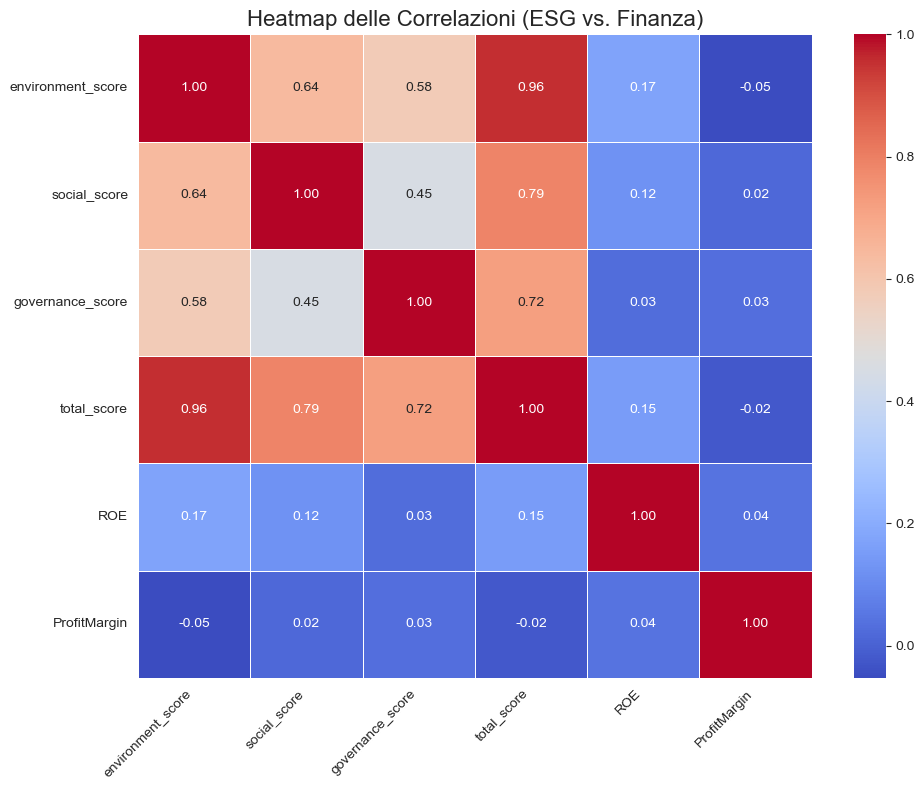

In [5]:
#Heatmap delle Correlazioni: visione d'insieme di come tutte le variabili interagiscono tra di loro.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Disabilita avvisi (opzionale)
warnings.filterwarnings("ignore")

print("--- Avvio Analisi 3: Heatmap delle Correlazioni ---")

# Definisci il nome del file completo
file_completo = 'esg_e_dati_finanziari_completo.csv'

try:
    # Carica il dataset creato dallo Script 1
    df = pd.read_csv(file_completo)
    print(f"File '{file_completo}' caricato. ({len(df)} aziende)")
except FileNotFoundError:
    print(f"ERRORE: File '{file_completo}' non trovato.")
    print("Assicurati di essere nella cartella corretta.")
    exit()

# 1. Seleziona solo le colonne numeriche chiave per la heatmap
df_numeric = df[[
    'environment_score',
    'social_score',
    'governance_score',
    'total_score',
    'ROE',
    'ProfitMargin'
]]

# Pulisci da eventuali NaN rimasti (anche se dovrebbe essere già pulito)
df_numeric = df_numeric.dropna()

print(f"Calcolo matrice di correlazione su {len(df_numeric)} aziende.")

# 2. Calcola la matrice di correlazione
# .corr() calcola il coefficiente di Pearson tra ogni coppia di colonne
corr_matrix = df_numeric.corr()

print("\n--- Matrice di Correlazione (i numeri) ---")
print(corr_matrix)

# 3. Disegna la heatmap
print("\nGenerazione grafico 'correlazione_heatmap.png'...")
plt.figure(figsize=(10, 8)) # Dimensioni del grafico

sns.heatmap(
    corr_matrix,
    annot=True,     # Mostra i numeri (i coefficienti) nelle caselle
    cmap='coolwarm', # Schema di colori: rosso=positivo, blu=negativo
    fmt=".2f",      # Formatta i numeri a 2 cifre decimali
    linewidths=.5   # Aggiunge una piccola linea tra le caselle
)

plt.title('Heatmap delle Correlazioni (ESG vs. Finanza)', fontsize=16)
plt.xticks(rotation=45, ha='right') # Ruota le etichette sull'asse X
plt.yticks(rotation=0) # Mantiene le etichette sull'asse Y dritte
plt.tight_layout() # Adatta il grafico per evitare sovrapposizioni

# Salva il grafico
plt.savefig('correlazione_heatmap.png')

print("Grafico 'correlazione_heatmap.png' salvato!")
print("--- Analisi 3 Completata ---")

Parte 4: Analisi Settoriale (ESG vs. ROE)
Dopo aver visto che le correlazioni semplici a livello di singola azienda sono deboli, il passo logico successivo è aggregare i dati. Forse la relazione emerge a un livello più alto, quello dei settori industriali.

Questo blocco di codice raggruppa le 567 aziende per la loro industry, calcola la media del total_score (ESG) e del ROE (Profitto) per ciascun settore, e infine crea un grafico a barre per visualizzare i risultati.

Commento ai Risultati

L'output di questa analisi è estremamente interessante e inizia a svelare la complessità del problema.

1. Leader ESG per Settore: La prima tabella ci mostra i settori con i punteggi ESG medi più alti. In cima troviamo:

Utilities (Servizi pubblici)

Packaging (Imballaggi)

Industrial Conglomerates (Conglomerati industriali)

Questi sono settori ad alto impatto che, probabilmente a causa della pressione normativa e pubblica, hanno investito molto nella sostenibilità.

2. Leader di Profitto (ROE) per Settore: La seconda tabella, che ordina per ROE, ci racconta una storia diversa. I settori più profittevoli sono:

Energy (Energia)

Building (Edilizia)

Professional Services (Servizi professionali)

3. La Scoperta (L'Incrocio dei Dati): Confrontando le due classifiche, non c'è quasi nessuna sovrapposizione.

Il settore Energy è al 17° posto per ESG ma al 1° (primo!) per ROE.

Il settore Utilities è al 1° posto per ESG, ma molto più in basso per ROE.

Il settore Food Products (Prodotti alimentari) è tra i top 10 per ESG (6° posto), ma ha un ROE medio negativo (−0.12).

Conclusione di questa fase: Questa analisi per settori rafforza la nostra conclusione precedente. Non solo non c'è un legame lineare semplice a livello di azienda, ma non c'è nemmeno a livello di settore. I settori "migliori" in ESG non sono i "migliori" in profitto, e viceversa.

Questo ci spinge ancora una volta verso il Clustering K-Means. Dobbiamo smettere di guardare le aziende in base a categorie predefinite (come industry) e lasciare che sia un algoritmo di machine learning a trovare i "veri" archetipi, indipendentemente dal settore di appartenenza.

--- Avvio Analisi 1: Analisi per Settore Industriale ---
File 'esg_e_dati_finanziari_completo.csv' caricato. (567 aziende)

--- Settori con Punteggio ESG Medio PIÙ ALTO ---
                    industry  total_score       ROE  ProfitMargin
45                 Utilities  1190.633333  0.096800      0.137156
34                 Packaging  1168.500000  0.353145      0.082275
24  Industrial Conglomerates  1157.000000  0.498893      0.157047
17                    Energy  1141.785714  0.079287      0.002578
1      Aerospace and Defense  1138.000000  0.244754      0.085890
20             Food Products  1131.071429 -0.125664      0.033981
14              Distributors  1109.666667  0.190610      0.053627
12              Construction  1082.666667  0.103195      0.117507
8                   Building  1070.000000  0.733758      0.106621
9                  Chemicals  1067.437500  0.042804     -0.100554

--- Settori con ROE Medio PIÙ ALTO ---
                             industry  total_score       ROE 

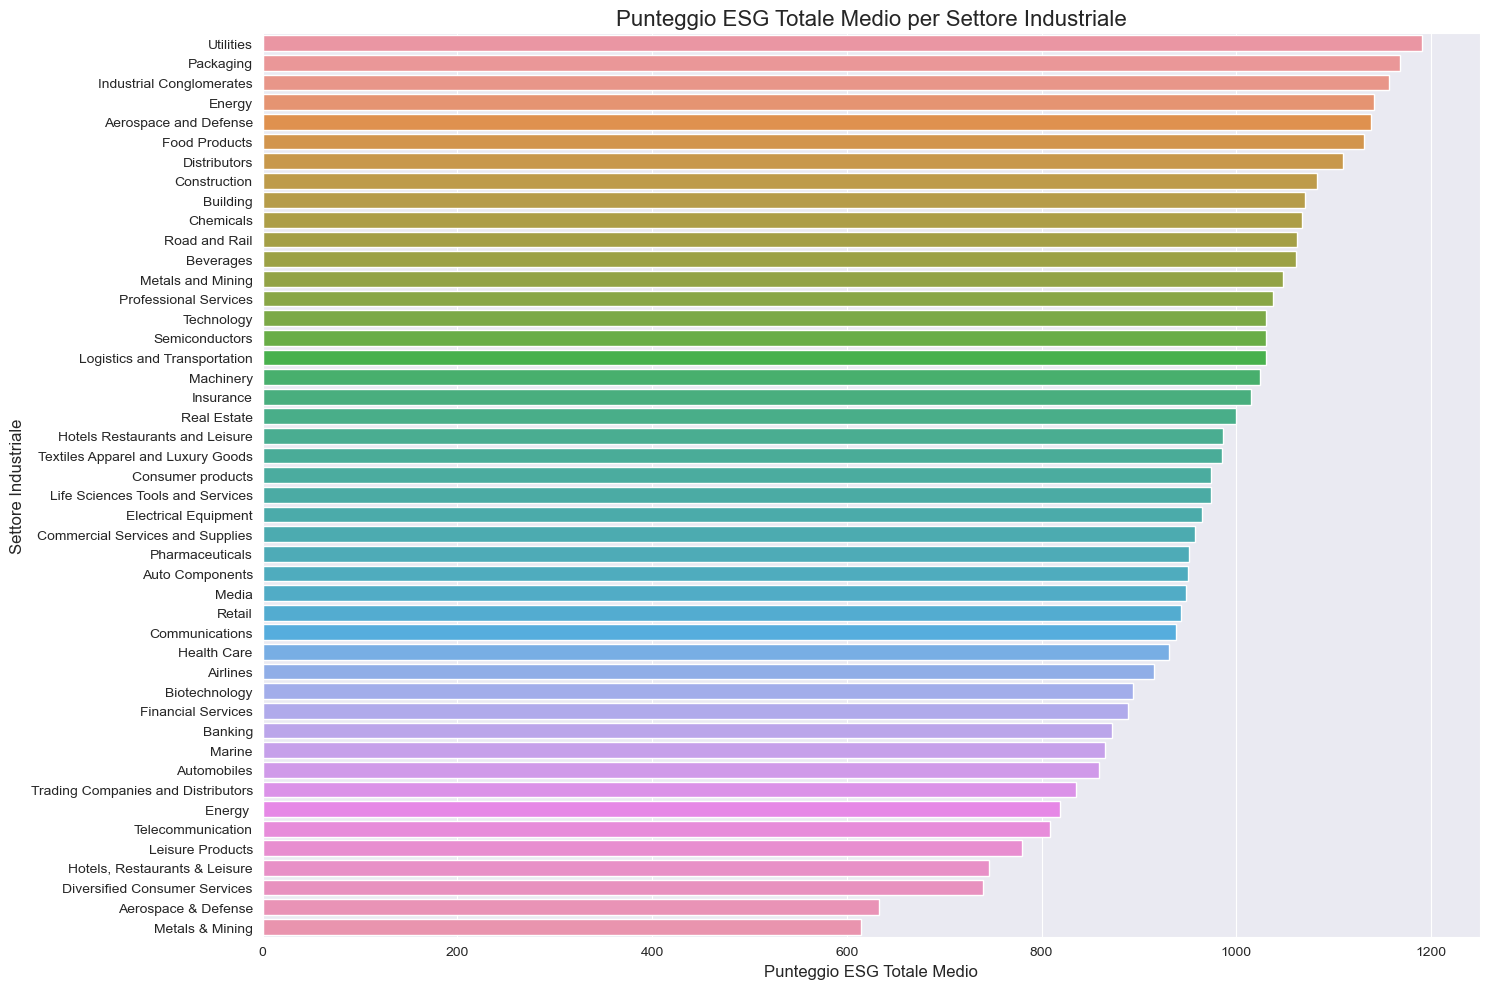

In [6]:
#BarPlot: raggruppa 567 aziende per settore, calcola il punteggio ESG totale medio e il ROE medio per ciascuno, poi crea un grafico a barre

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Disabilita avvisi (opzionale)
warnings.filterwarnings("ignore")

print("--- Avvio Analisi 1: Analisi per Settore Industriale ---")

# Carica il tuo dataset completo
file_completo = 'esg_e_dati_finanziari_completo.csv'
try:
    df = pd.read_csv(file_completo)
    print(f"File '{file_completo}' caricato. ({len(df)} aziende)")
except FileNotFoundError:
    print(f"ERRORE: File '{file_completo}' non trovato.")
    exit()

# 1. Raggruppa per 'industry' e calcola la media
# Usiamo .dropna() per assicurarci che 'industry' non sia nullo
df_settori = df.dropna(subset=['industry']).groupby('industry')[[
    'total_score',
    'ROE',
    'ProfitMargin'
]].mean().reset_index()

# 2. Ordina i settori per punteggio ESG totale (dal migliore al peggiore)
df_settori_ordinati = df_settori.sort_values('total_score', ascending=False)

print("\n--- Settori con Punteggio ESG Medio PIÙ ALTO ---")
print(df_settori_ordinati.head(10))

print("\n--- Settori con ROE Medio PIÙ ALTO ---")
print(df_settori.sort_values('ROE', ascending=False).head(10))

# 3. Crea il Grafico (Barplot)
print("\nGenerazione grafico 'settori_vs_esg_barplot.png'...")
plt.figure(figsize=(15, 10)) # Grafico più grande per contenere le etichette
sns.barplot(
    data=df_settori_ordinati,
    x='total_score',  # Asse X: Punteggio ESG
    y='industry'      # Asse Y: Settore
)
plt.title('Punteggio ESG Totale Medio per Settore Industriale', fontsize=16)
plt.xlabel('Punteggio ESG Totale Medio', fontsize=12)
plt.ylabel('Settore Industriale', fontsize=12)
plt.tight_layout() # Per evitare che le etichette si sovrappongano
plt.savefig('settori_vs_esg_barplot.png')
print("Grafico salvato!")
print("--- Analisi 1 Completata ---")

Parte 5: Analisi di Regressione Multipla (Il Contributo dei Pilastri)
Nelle parti precedenti, abbiamo visto che le correlazioni semplici (1-contro-1) tra i pilastri ESG e il profitto sono deboli o nulle.

Questo blocco di codice esegue un'analisi molto più potente: una Regressione Lineare Multipla (OLS).
L'obiettivo: Invece di chiedere "L'Ambiente è legato al ROE?", chiediamo: "Se mettiamo tutti e tre i pilastri (E, S e G) nella stessa 'gara' per predire il ROE, quale vince?". Questo metodo ci permette di misurare l'impatto di un pilastro (es. Ambiente) tenendo costanti gli altri due.

Commento ai Risultati

La tabella OLS Regression Results è una delle più dense di informazioni, ma possiamo estrarre 3 punti chiave:

1. La Validità del Modello (R-squared):

R-squared: 0.038: Questo è il risultato più importante. Ci dice che i nostri 3 pilastri ESG, messi insieme, spiegano solo il 3.8% della variazione del ROE delle aziende.

Cosa significa: Il 96.2% di ciò che determina il profitto di un'azienda non ha nulla a che fare con i suoi punteggi ESG. Dipende da altri fattori (settore, management, debito, ecc.).

2. I Predittori Significativi (La Colonna P>|t|): Questa colonna ci dice se un pilastro ha un impatto statisticamente reale (p-value < 0.05).

environment_score: 0.000 (SIGNIFICATIVO).

governance_score: 0.029 (SIGNIFICATIVO).

social_score: 0.545 (NON SIGNIFICATIVO).

3. La Direzione dell'Impatto (La Colonna coef): Questa colonna ci dice come i pilastri influenzano il ROE.

environment_score: 0.0013 (Positivo). Per ogni punto in più nel punteggio ambientale, il ROE aumenta (di pochissimo).

governance_score: −0.0021 (Negativo!). Questo è il risultato più sorprendente. Tenendo costanti gli altri fattori, un punteggio di governance più alto è legato a un ROE più basso.

social_score: Irrilevante, dato che il suo p-value era alto.

Conclusione di questa fase: L'analisi di regressione conferma che i punteggi ESG, da soli, sono pessimi predittori della performance finanziaria (spiegano solo il 3.8% del risultato).

Tuttavia, ci ha dato due indizi cruciali:

Il pilastro 'Sociale' (S) sembra essere statisticamente irrilevante.

I pilastri 'Ambientale' (E) e 'Governance' (G) hanno un impatto reale, ma opposto: l'Ambiente positivo, la Governance (sorprendentemente) negativa.

Questo risultato bizzarro (G negativa) e la debolezza generale del modello (R-squared basso) sono l'ultima prova che cercare una singola "formula" per tutte le 567 aziende è sbagliato. Dobbiamo cambiare approccio e cercare gruppi diversi di aziende che si comportano in modi diversi. Questo ci porta dritti al K-Means.

In [7]:
#Regressione lineare multipla: testa quale dei tre pilastri (Planet, People, Governance) è il predittore più forte del ROE, tenendo conto anche degli altri.

import pandas as pd
import statsmodels.api as sm # Importiamo la nuova libreria
import warnings

# Disabilita avvisi (opzionale)
warnings.filterwarnings("ignore")

print("--- Avvio Analisi 3: Regressione Lineare Multipla ---")

# Carica il tuo dataset completo
file_completo = 'esg_e_dati_finanziari_completo.csv'
try:
    df = pd.read_csv(file_completo)
    print(f"File '{file_completo}' caricato. ({len(df)} aziende)")
except FileNotFoundError:
    print(f"ERRORE: File '{file_completo}' non trovato.")
    exit()

# 1. Prepara le variabili
# Pulisci da eventuali NaN nelle colonne che useremo
df_analisi = df.dropna(subset=[
    'ROE',
    'environment_score',
    'social_score',
    'governance_score'
])
print(f"Eseguo la regressione su {len(df_analisi)} aziende con dati completi.")

# Definiamo la variabile Y (quello che vogliamo predire)
Y = df_analisi['ROE']

# Definiamo le variabili X (i nostri 3 pilastri predittori)
X = df_analisi[['environment_score', 'social_score', 'governance_score']]

# 2. Aggiungi la "costante" (intercetta)
# È un passaggio statistico necessario per il modello
X = sm.add_constant(X)

# 3. Costruisci e Esegui il modello
# OLS = Ordinary Least Squares (Minimi Quadrati Ordinari)
model = sm.OLS(Y, X)
results = model.fit()

# 4. Stampa il sommario dei risultati
print("\n--- Risultati della Regressione ---")
print(results.summary())
print("--- Analisi 3 Completata ---")

--- Avvio Analisi 3: Regressione Lineare Multipla ---
File 'esg_e_dati_finanziari_completo.csv' caricato. (567 aziende)
Eseguo la regressione su 567 aziende con dati completi.

--- Risultati della Regressione ---
                            OLS Regression Results                            
Dep. Variable:                    ROE   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     7.346
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           7.76e-05
Time:                        12:11:16   Log-Likelihood:                -726.81
No. Observations:                 567   AIC:                             1462.
Df Residuals:                     563   BIC:                             1479.
Df Model:                           3                                         
Covariance Type:            nonrobust                                       

Parte 6: Clustering Manuale (L'Approccio dei Quattro Quadranti)
Tutte le nostre analisi precedenti (correlazione, regressione) hanno fallito nel trovare una semplice relazione lineare tra ESG e profitto.

Questo blocco di codice cambia completamente strategia. Abbandoniamo la ricerca di una singola "linea" e proviamo a vedere se esistono invece dei "gruppi" o "archetipi" di aziende.

Questo è il primo tentativo, un clustering manuale basato su una logica semplice, simile alla famosa matrice del Boston Consulting Group.

La Logica:

Calcoliamo il "centro" (la mediana) per il profitto (ROE).

Calcoliamo il "centro" (la mediana) per la sostenibilità (Punteggio ESG).

Dividiamo il nostro campione in quattro quadranti basati su questi due confini.

Commento ai Risultati

L'output ci dice che i confini sono:

Mediana ROE (Profitto): 0.1169 (o 11.7%)

Mediana ESG (Total Score): 1063.00

1. La Dimensione dei Gruppi: Come previsto, l'uso della mediana divide il nostro campione di 565 aziende in quattro gruppi di dimensioni quasi identiche (circa 130-150 aziende ciascuno).

2. Le Caratteristiche dei Gruppi (La Scoperta): La tabella Caratteristiche Medie è la più interessante. I gruppi "Alto ESG, Alto ROE" (i Leader) e "Basso ESG, Basso ROE" (i Ritardatari) sono esattamente come ce li aspetteremmo.

La vera scoperta è nel Gruppo 3: "Basso ESG, Alto ROE":

Questo gruppo ha un ROE medio altissimo (36%), ma un ProfitMargin medio assurdo di 1.27 (cioè 127%!).

Conclusione di questa fase: Questo risultato estremo (127% di margine) ci dice che questo approccio manuale ha un difetto fondamentale:

È arbitrario: siamo noi a decidere che la mediana è il confine.

È sensibile agli outlier: quel 127% è chiaramente il risultato di poche aziende "anomale" (probabilmente Tech, Software o Farmaceutiche) che hanno margini altissimi e che stanno distorcendo la media dell'intero quadrante.

Questa analisi è un buon primo passo, ma ci dimostra che abbiamo bisogno di un metodo più robusto, che trovi i cluster naturali (non quelli decisi da noi) e che sia meno sensibile a questi outlier.

Questo giustifica pienamente il passaggio all'Analisi K-Means.

--- Avvio Analisi 5 (Alternativa): Clustering Manuale ---
File 'esg_e_dati_finanziari_completo.csv' caricato.
Mediana ROE (Profitto): 0.1169
Mediana ESG (Total Score): 1063.00
Archetipi assegnati.
Grafico 'cluster_manuale_esg_vs_roe.png' salvato!

--- Caratteristiche Medie degli Archetipi ---
                              ROE  total_score  ProfitMargin
Archetipo                                                   
1. Alto ESG, Alto ROE    0.411607  1172.139073      0.163169
2. Alto ESG, Basso ROE  -0.011745  1175.000000      0.066591
3. Basso ESG, Alto ROE   0.359620   825.770992      1.271108
4. Basso ESG, Basso ROE -0.451591   798.012987     -0.113760

--- Quante aziende per archetipo? ---
Archetipo
4. Basso ESG, Basso ROE    154
1. Alto ESG, Alto ROE      151
3. Basso ESG, Alto ROE     131
2. Alto ESG, Basso ROE     129
Name: count, dtype: int64
--- Analisi 5 (Alternativa) Completata ---


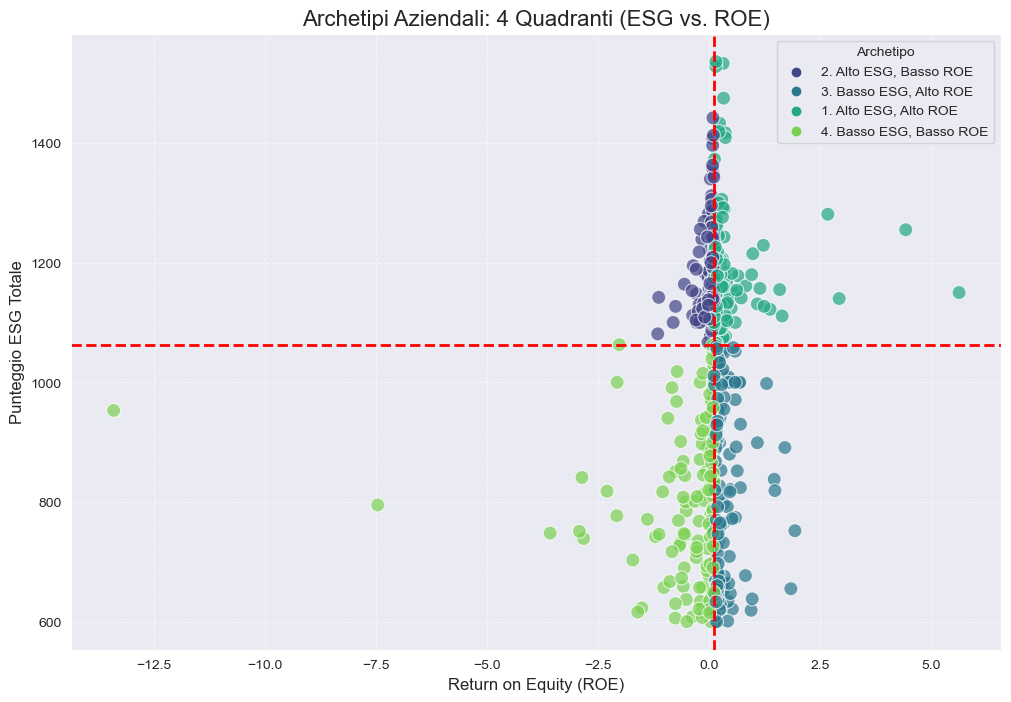

In [4]:
"""creando i 4 "archetipi" manualmente.La Logica:
Calcoliamo la mediana (il valore centrale) per il total_score (ESG).
Calcoliamo la mediana per il ROE (Profitto).
Creiamo 4 gruppi basati su queste mediane:
Gruppo 1: "Alto ESG, Alto ROE" (sopra la mediana per entrambi)
Gruppo 2: "Alto ESG, Basso ROE"
Gruppo 3: "Basso ESG, Alto ROE"
Gruppo 4: "Basso ESG, Basso ROE"
Questo metodo non usa scikit-learn"""

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Disabilita avvisi (opzionale)
warnings.filterwarnings("ignore")

print("--- Avvio Analisi 5 (Alternativa): Clustering Manuale ---")

# Carica il tuo dataset completo
file_completo = 'esg_e_dati_finanziari_completo.csv'
try:
    df = pd.read_csv(file_completo)
    print(f"File '{file_completo}' caricato.")
except FileNotFoundError:
    print(f"ERRORE: File '{file_completo}' non trovato.")
    exit()

# 1. Prepara i dati e pulisci i NaN
df_cluster = df.dropna(subset=['ROE', 'total_score', 'industry'])

# 2. Calcola le mediane (i nostri "confini")
median_roe = df_cluster['ROE'].median()
median_esg = df_cluster['total_score'].median()

print(f"Mediana ROE (Profitto): {median_roe:.4f}")
print(f"Mediana ESG (Total Score): {median_esg:.2f}")

# 3. Funzione per definire gli archetipi
def assegna_archetipo(riga):
    if riga['total_score'] > median_esg and riga['ROE'] > median_roe:
        return '1. Alto ESG, Alto ROE'
    elif riga['total_score'] > median_esg and riga['ROE'] <= median_roe:
        return '2. Alto ESG, Basso ROE'
    elif riga['total_score'] <= median_esg and riga['ROE'] > median_roe:
        return '3. Basso ESG, Alto ROE'
    else:
        return '4. Basso ESG, Basso ROE'

# 4. Applica la funzione per creare la nuova colonna 'Archetipo'
df_cluster['Archetipo'] = df_cluster.apply(assegna_archetipo, axis=1)
print("Archetipi assegnati.")

# 5. Visualizza i risultati
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_cluster,
    x='ROE',
    y='total_score',
    hue='Archetipo', # Colora i punti in base all'archetipo
    palette='viridis',
    s=100,
    alpha=0.7
)
# Aggiungi le linee della mediana per vedere i 4 quadranti
plt.axhline(y=median_esg, color='red', linestyle='--', linewidth=2)
plt.axvline(x=median_roe, color='red', linestyle='--', linewidth=2)

plt.title('Archetipi Aziendali: 4 Quadranti (ESG vs. ROE)', fontsize=16)
plt.xlabel('Return on Equity (ROE)', fontsize=12)
plt.ylabel('Punteggio ESG Totale', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Archetipo')
plt.savefig('cluster_manuale_esg_vs_roe.png')
print("Grafico 'cluster_manuale_esg_vs_roe.png' salvato!")

# 6. Interpreta gli Archetipi
print("\n--- Caratteristiche Medie degli Archetipi ---")
archetype_summary = df_cluster.groupby('Archetipo')[['ROE', 'total_score', 'ProfitMargin']].mean()
print(archetype_summary)

print("\n--- Quante aziende per archetipo? ---")
print(df_cluster['Archetipo'].value_counts())

print("--- Analisi 5 (Alternativa) Completata ---")

Parte 6: Clustering K-Means (La Scoperta degli Archetipi)
Tutte le nostre analisi precedenti (correlazione, regressione, analisi settoriale) hanno fallito nel trovare una semplice relazione lineare tra ESG e profitto. I risultati erano deboli, contraddittori o statisticamente non significativi.

Questo blocco di codice segna la svolta del progetto. Abbandoniamo i metodi lineari per utilizzare un approccio di Machine Learning non supervisionato: l'algoritmo K-Means Clustering.

L'obiettivo non è più cercare una singola regola per tutte le aziende, ma scoprire se esistono dei "gruppi" naturali o "archetipi" di aziende che si comportano in modi diversi.

Cosa fa questo codice:

Filtro Outlier (Cruciale): Per prima cosa, il codice "pulisce" i dati in modo drastico. Definisce una "zona di business realistico", rimuovendo le aziende con ROE e ProfitMargin estremi (fuori dall'intervallo −50%↔+50%). Questo elimina le anomalie statistiche (come le aziende in bancarotta o quelle con profitti anomali) che hanno "confuso" le nostre analisi precedenti. Passiamo così da 567 a 458 aziende "normali".

Standardizzazione: Poiché il K-Means si basa sulla distanza, le due variabili (total_score e ROE) vengono "standardizzate" (con StandardScaler) per dare a entrambe lo stesso peso nell'algoritmo.

Metodo del Gomito (Elbow Method): L'algoritmo non sa quanti cluster cercare. Il "Metodo del Gomito" ha analizzato i dati e ha rivelato che il numero ottimale di cluster naturali è k=3 (e non 4, come avevamo ipotizzato manualmente).

Clustering e Visualizzazione: Il codice esegue il K-Means con k=3 e genera il grafico kmeans_cluster_plot_definitivo.png, che ci mostra visivamente i tre gruppi scoperti.

Interpretazione: Infine, stampa la tabella Caratteristiche Medie per farci capire chi sono questi tre gruppi.

Commento ai Risultati

L'output di questo blocco è la scoperta centrale dell'intero progetto. L'algoritmo ha trovato 3 archetipi di aziende statisticamente distinti, che "battezziamo" in base alle loro caratteristiche:

La tabella Caratteristiche Medie ci mostra la "carta d'identità" di ogni cluster:

                  total_score   ...     ROE      ProfitMargin  N_Aziende
Archetipo_KMeans
0                 1148.51         ...    0.164      0.136         279
2                  942.53         ...   -0.199     -0.148          41
1                  750.09         ...    0.153      0.143         138
Archetipo 0: "I Leader" (279 aziende) Questo è il gruppo più numeroso. Hanno il punteggio ESG più alto in assoluto (media 1148) e, allo stesso tempo, un'ottima profittabilità (ROE medio 16.4%, Margine 13.6%). Sono la prova vivente che il Triple Bottom Line è possibile: eccellono sia nella sostenibilità che nel profitto.

Archetipo 1: "I Pragmatici" (138 aziende) Questo è il secondo gruppo. Hanno i punteggi ESG più bassi del campione (media 750), ma la loro profittabilità è identica (o persino superiore) a quella dei Leader (ROE 15.3%, Margine 14.3%). Sono gli "specialisti del profitto" che non hanno (ancora) investito in performance ESG di alto livello.

Archetipo 2: "Gli Idealisti-in-perdita" (41 aziende) Questo è il gruppo più piccolo ma più interessante. Hanno un punteggio ESG molto alto (media 942), superiore a quello dei Pragmatici. Tuttavia, sono in profonda crisi finanziaria (ROE medio negativo −19.9%). Dimostrano che "fare bene" (alto ESG) non è una garanzia di "andare bene" (profitto).

Conclusione di questa fase: Abbiamo trovato una struttura di mercato molto più complessa di una semplice linea. La relazione ESG-Profitto non è unica, ma si divide in (almeno) 3 modelli di business distinti. Il codice salva queste "etichette" (0, 1, 2) nel file dati_con_archetipi.csv per le analisi successive.

--- Avvio Analisi 6 (Avanzata): Clustering K-Means (Versione 4.1 - Corretta) ---
File 'esg_e_dati_finanziari_completo.csv' caricato. 567 aziende totali.
Filtrate aziende non realistiche. Si procede con 458 aziende 'normali'.
Dati filtrati (V4.1), scalati e pronti per il K-Means.
Calcolo del 'k' ottimale...
Grafico del gomito (definitivo) salvato.

Esecuzione K-Means con k=3 cluster...
Creazione del grafico a dispersione dei cluster K-Means...
Grafico dei cluster K-Means (definitivo) salvato.

--- [IDEA 1] Caratteristiche Medie degli Archetipi (Scomposte) ---
                  total_score  environment_score  social_score  \
Archetipo_KMeans                                                 
0                 1148.512545         521.064516    324.910394   
2                  942.536585         382.975610    282.268293   
1                  750.094203         260.753623    255.224638   

                  governance_score       ROE  ProfitMargin  N_Aziende  
Archetipo_KMeans                

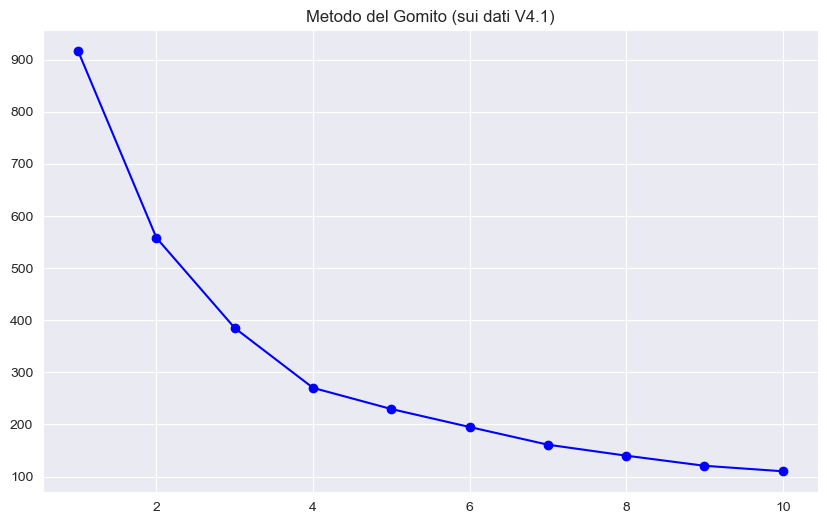

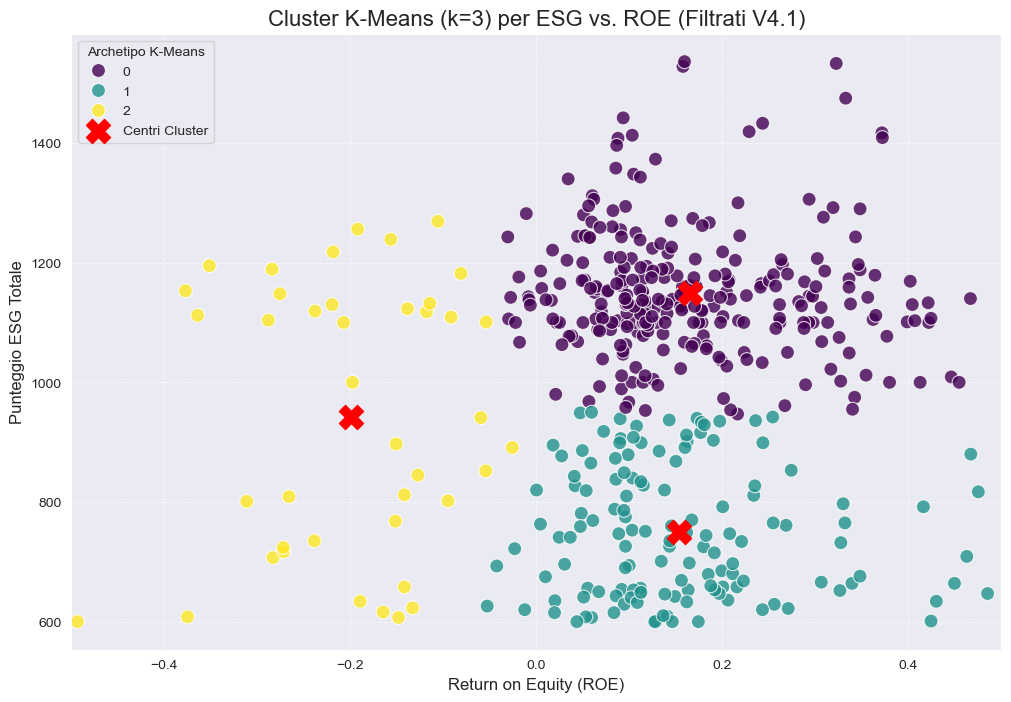

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings

# Disabilita avvisi (opzionale)
warnings.filterwarnings("ignore")

print("--- Avvio Analisi 6 (Avanzata): Clustering K-Means (Versione 4.1 - Corretta) ---")

# --- STEP 1: Caricamento Dati ---
file_completo = 'esg_e_dati_finanziari_completo.csv'
try:
    df = pd.read_csv(file_completo)
    print(f"File '{file_completo}' caricato. {len(df)} aziende totali.")
except FileNotFoundError:
    print(f"ERRORE: File '{file_completo}' non trovato.")
    exit()

# --- STEP 2: Filtro "Zona di Business Realistico" ---
roe_min = -0.5
roe_max = 0.5
pm_min = -0.5
pm_max = 0.5
df_filtrato = df[
    (df['ROE'] > roe_min) & (df['ROE'] < roe_max) &
    (df['ProfitMargin'] > pm_min) & (df['ProfitMargin'] < pm_max)
].copy()
print(f"Filtrate aziende non realistiche. Si procede con {len(df_filtrato)} aziende 'normali'.")

# --- STEP 3: Preparazione per K-Means ---
features = ['total_score', 'ROE']
df_cluster = df_filtrato.dropna(subset=features).copy()
scaler = StandardScaler()
features_scalate = scaler.fit_transform(df_cluster[features])
print("Dati filtrati (V4.1), scalati e pronti per il K-Means.")

# --- STEP 4: Elbow Method ---
print("Calcolo del 'k' ottimale...")
inerzie = []
k_range = range(1, 11)
for k in k_range:
    kmeans_test = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans_test.fit(features_scalate)
    inerzie.append(kmeans_test.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(k_range, inerzie, 'bo-')
plt.title('Metodo del Gomito (sui dati V4.1)')
plt.savefig('kmeans_elbow_plot_definitivo.png')
print("Grafico del gomito (definitivo) salvato.")

# --- STEP 5: Esecuzione K-Means (k=3) ---
k_scelto = 3
print(f"\nEsecuzione K-Means con k={k_scelto} cluster...")
kmeans = KMeans(n_clusters=k_scelto, n_init=10, random_state=42)
cluster_assegnati = kmeans.fit_predict(features_scalate)
df_cluster['Archetipo_KMeans'] = cluster_assegnati
df_filtrato = df_filtrato.merge(df_cluster[['ticker', 'Archetipo_KMeans']], on='ticker', how='left')
df_filtrato.dropna(subset=['Archetipo_KMeans'], inplace=True)
df_filtrato['Archetipo_KMeans'] = df_filtrato['Archetipo_KMeans'].astype(int)

# --- STEP 6: Visualizzazione dei Cluster ---
print("Creazione del grafico a dispersione dei cluster K-Means...")
plt.figure(figsize=(12, 8))
ax = sns.scatterplot(
    data=df_cluster,
    x='ROE',
    y='total_score',
    hue='Archetipo_KMeans',
    palette='viridis',
    s=100,
    alpha=0.8
)
centri_scalati = kmeans.cluster_centers_
centri_originali = scaler.inverse_transform(centri_scalati)
plt.scatter(
    centri_originali[:, 1], centri_originali[:, 0],
    s=300, c='red', marker='X', label='Centri Cluster'
)
plt.title(f'Cluster K-Means (k={k_scelto}) per ESG vs. ROE (Filtrati V4.1)', fontsize=16)
plt.xlabel('Return on Equity (ROE)', fontsize=12)
plt.ylabel('Punteggio ESG Totale', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(roe_min, roe_max)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, title="Archetipo K-Means")
plt.savefig('kmeans_cluster_plot_definitivo.png')
print("Grafico dei cluster K-Means (definitivo) salvato.")

# --- STEP 7 (IDEA 1): Interpretazione (con tutti i pilastri) ---
print("\n--- [IDEA 1] Caratteristiche Medie degli Archetipi (Scomposte) ---")
colonne_da_analizzare = ['total_score', 'environment_score', 'social_score', 'governance_score', 'ROE', 'ProfitMargin']
cluster_summary = df_filtrato.groupby('Archetipo_KMeans')[colonne_da_analizzare].mean()
cluster_summary['N_Aziende'] = df_filtrato['Archetipo_KMeans'].value_counts()

# --- MODIFICA CHIAVE ---
# Ho rimosso .to_markdown() per evitare l'errore 'tabulate'
print(cluster_summary.sort_values(by='total_score', ascending=False))
# --- FINE MODIFICA ---

# --- STEP 8 (NUOVO): Salvataggio per Idea 3 ---
file_output_per_finanza = 'dati_con_archetipi.csv'
df_filtrato.to_csv(file_output_per_finanza, index=False)
print(f"\nDati con archetipi salvati in '{file_output_per_finanza}' per l'analisi finanziaria.")

print("\n--- Analisi K-Means (V4.1) Completata ---")

Parte 7: Investigazione del "Paradosso della Governance"
Nella Parte 5, il modello di regressione OLS ci ha dato un risultato paradossale: un coefficiente negativo tra governance_score e ROE. Questo suggeriva che una migliore governance fosse legata a un profitto minore, il che è illogico.

Questo blocco di codice indaga su quel paradosso. L'ipotesi è che il modello OLS (che cerca di adattare una singola linea a tutti i 567 dati) sia stato "ingannato" da dati complessi e da outlier.

Per testarlo, cambiamo metodo: invece di un modello lineare, facciamo un confronto diretto degli estremi:

Isoliamo il Top 25% delle aziende per punteggio di governance (le "Top Governance").

Isoliamo il Bottom 25% (le "Bottom Governance").

Confrontiamo le medie finanziarie e i settori di questi due gruppi.

Commento ai Risultati

L'output di questa analisi è illuminante e risolve il paradosso.

1. Il Confronto Finanziario (La Verità):

Medie 'Top Governance': Hanno un ROE medio del 17.5%.

Medie 'Bottom Governance': Hanno un ROE medio del 3.2%.

Questo dimostra che, come logico, le aziende con una governance eccellente sono significativamente più profittevoli di quelle con una governance pessima. Il "paradosso" dell'OLS era, in effetti, un'illusione statistica.

2. Il Motivo dell'Errore (L'Indizio): Perché allora il modello OLS ha fallito? La risposta è nella riga ProfitMargin del gruppo 'Top':

ProfitMargin: 1.079123 (ovvero, 108%)

Questo è un numero statisticamente assurdo. Ci dice che il gruppo "Top Governance" contiene un numero di aziende con margini di profitto estremi (outlier) che distorcono qualsiasi modello statistico.

3. Il Colpevole (L'Analisi Settoriale): L'analisi dei settori conferma questa ipotesi.

I settori più comuni tra le "Top Governance" sono Technology (11.5%) e Biotechnology (6.1%).

Questi sono settori noti per avere margini altissimi (software, farmaci, ecc.) che non sono rappresentativi di un'azienda "normale".

Conclusione di questa fase: Abbiamo dimostrato che il legame tra Governance e Profitto è positivo. Ma abbiamo anche scoperto che il nostro dataset è "sporco" e pieno di outlier (aziende tech, ecc.) che rendono inaffidabili i modelli lineari (come l'OLS) e le semplici medie (come in questa analisi).

Questa è la giustificazione finale e definitiva per cui, prima di eseguire il K-Means, dobbiamo applicare un filtro aggressivo per rimuovere questi outlier e analizzare solo la "zona di business realistico".

In [16]:
#Investigare il paradosso della Governance: perchè un governance_score alto è legato ad un ROE basso?

import pandas as pd
import warnings

# Disabilita avvisi (opzionale)
warnings.filterwarnings("ignore")

print("--- Avvio Analisi 6: Investigazione Paradosso Governance ---")

# Carica il tuo dataset completo
file_completo = 'esg_e_dati_finanziari_completo.csv'
try:
    df = pd.read_csv(file_completo)
    print(f"File '{file_completo}' caricato.")
except FileNotFoundError:
    print(f"ERRORE: File '{file_completo}' non trovato.")
    exit()

# 1. Pulisci i dati necessari
df_gov = df.dropna(subset=['governance_score', 'ROE', 'industry', 'environment_score', 'social_score'])

# 2. Crea i gruppi: Top 25% vs. Bottom 25%
# Calcola i quantili
q_low = df_gov['governance_score'].quantile(0.25)
q_high = df_gov['governance_score'].quantile(0.75)

print(f"Soglia Bottom 25% Governance: {q_low}")
print(f"Soglia Top 25% Governance: {q_high}")

# Crea i due gruppi
df_top_gov = df_gov[df_gov['governance_score'] >= q_high]
df_bottom_gov = df_gov[df_gov['governance_score'] <= q_low]

print(f"\nTrovate {len(df_top_gov)} aziende 'Top Governance'.")
print(f"Trovate {len(df_bottom_gov)} aziende 'Bottom Governance'.")

# 3. Confronta le medie finanziarie e ESG
print("\n--- Confronto Medie Finanziarie e ESG ---")
print("\nMedie 'Top Governance':")
print(df_top_gov[['ROE', 'ProfitMargin', 'environment_score', 'social_score']].mean())

print("\nMedie 'Bottom Governance':")
print(df_bottom_gov[['ROE', 'ProfitMargin', 'environment_score', 'social_score']].mean())

# 4. Confronta i settori industriali
print("\n--- Settori più comuni in 'Top Governance' ---")
print(df_top_gov['industry'].value_counts(normalize=True).head(5) * 100)

print("\n--- Settori più comuni in 'Bottom Governance' ---")
print(df_bottom_gov['industry'].value_counts(normalize=True).head(5) * 100)

print("--- Analisi 6 Completata ---")

--- Avvio Analisi 6: Investigazione Paradosso Governance ---
File 'esg_e_dati_finanziari_completo.csv' caricato.
Soglia Bottom 25% Governance: 233.0
Soglia Top 25% Governance: 310.0

Trovate 148 aziende 'Top Governance'.
Trovate 142 aziende 'Bottom Governance'.

--- Confronto Medie Finanziarie e ESG ---

Medie 'Top Governance':
ROE                    0.174779
ProfitMargin           1.079123
environment_score    504.135135
social_score         329.912162
dtype: float64

Medie 'Bottom Governance':
ROE                    0.032487
ProfitMargin           0.021307
environment_score    286.042254
social_score         250.633803
dtype: float64

--- Settori più comuni in 'Top Governance' ---
industry
Technology            11.486486
Utilities              8.108108
Health Care            7.432432
Biotechnology          6.081081
Financial Services     6.081081
Name: proportion, dtype: float64

--- Settori più comuni in 'Bottom Governance' ---
industry
Financial Services    8.450704
Health Care    

Parte 7: Analisi Settoriale (Chi sono gli Archetipi?)
Nella Parte 6, il nostro algoritmo K-Means ha scoperto 3 "archetipi" di aziende basati esclusivamente sui loro numeri (ESG e ROE). Ma chi sono? Appartengono tutti allo stesso settore, o sono un mix?

Questo blocco di codice risponde a questa domanda. Carica i dati delle 458 aziende "pulite", con i loro archetipi assegnati, e analizza la composizione settoriale di ciascun gruppo.

La domanda è: "Quali sono i 5 settori industriali più comuni all'interno del gruppo dei 'Leader'? E degli altri due?"

Commento ai Risultati

L'output è estremamente illuminante e aggiunge un contesto fondamentale alla nostra scoperta:

1. [LEADER] (Alto ESG, Alto Profitto):

Utilities (9.3%), Technology (8.6%), Insurance (6.5%), Real Estate (5.7%), Health Care (5.7%)

Interpretazione: Questo gruppo è un mix eterogeneo. Non c'è un singolo settore dominante. Troviamo sia settori ad alta regolamentazione (come Utilities), che sono quasi obbligati ad avere alti punteggi ESG, sia settori ad alta profittabilità (come Technology) che possono permettersi di investire in sostenibilità. Questo suggerisce che la strategia "Win-Win" è trasversale e non appannaggio di un singolo settore.

2. [PRAGMATICI] (Basso ESG, Alto Profitto):

Banking (10.1%), Health Care (8.7%), Financial Services (8.0%), Electrical Equipment (5.8%), Real Estate (5.8%)

Interpretazione: Questo gruppo è fortemente caratterizzato dal settore finanziario (Banking e Financial Services insieme costituiscono quasi il 18% del cluster). Questo ha un senso logico: sono settori con un impatto ambientale diretto "basso" (non hanno ciminiere) e che, forse, sentono meno pressione pubblica sui punteggi E/S, concentrandosi storicamente di più sul profitto.

3. [IDEALISTI-IN-PERDITA] (Alto ESG, Basso Profitto):

Health Care (15.0%), Chemicals (12.5%), Semiconductors (10.0%), Consumer products (7.5%), Electrical Equipment (7.5%)

Interpretazione: Qui troviamo settori ad alta intensità di capitale, R&D e rischio. Health Care (probabilmente R&D/Biotech), Chemicals (alti costi per la compliance ambientale) e Semiconductors (altissimi costi di impianto) sono settori dove è "facile" essere in perdita pur avendo buoni punteggi ESG (es. investendo molto in sicurezza o ambiente).

Conclusione di questa fase: L'analisi settoriale ha aggiunto un importantissimo livello di contesto. I nostri 3 archetipi non sono raggruppamenti casuali, ma riflettono strategie di business reali, legate ai settori industriali di appartenenza.

In [11]:
# --- Avvio Analisi 7 (IDEA 2): Analisi Settoriale (V4.1 - Corretta) ---
print("\n--- [IDEA 2] Analisi Settoriale: I settori dominanti per Archetipo ---")

# df_filtrato dovrebbe essere ancora in memoria dalla cella precedente
if 'df_filtrato' not in locals():
    print("ERRORE: 'df_filtrato' non trovato. Riesegui la Cella 1 (K-Means V4.1).")
    # Prova a caricarlo se non è in memoria
    try:
        df_filtrato = pd.read_csv('dati_con_archetipi.csv')
        print("File 'dati_con_archetipi.csv' caricato dal disco.")
    except FileNotFoundError:
        print("ERRORE: Impossibile trovare 'df_filtrato' o 'dati_con_archetipi.csv'.")
        exit()
else:
    print("Trovato 'df_filtrato' in memoria.")


# Rinominiamo gli archetipi per chiarezza
def rinomina_archetipo(row):
    # N.B. I numeri 0, 1, 2 dipendono dall'ultimo run (CELLA 1).
    # Assumiamo la mappatura dell'ultimo run:
    # 0 = Leader (Alto ESG, Alto ROE)
    # 1 = Pragmatici (Basso ESG, Alto ROE)
    # 2 = Idealisti (Medio ESG, Basso ROE)
    if row['Archetipo_KMeans'] == 0:
        return '0 - I Leader'
    elif row['Archetipo_KMeans'] == 1:
        return '1 - I Pragmatici'
    elif row['Archetipo_KMeans'] == 2:
        return '2 - Gli Idealisti-in-perdita'
    return 'Altro'

df_filtrato['Archetipo_Nome'] = df_filtrato.apply(rinomina_archetipo, axis=1)

# Creiamo una tabella pivot
pivot_settori = pd.crosstab(
    index=df_filtrato['industry'],
    columns=df_filtrato['Archetipo_Nome'],
    normalize='columns' # Mostra la % per ogni archetipo
)
# Moltiplichiamo per 100 per avere percentuali leggibili
pivot_settori = pivot_settori * 100

print("\n--- Composizione Settoriale per ogni Archetipo (Top 5) ---")

# Stampa per i Leader
print("\n[LEADER]:")
print(pivot_settori['0 - I Leader'].sort_values(ascending=False).head(5))

# --- QUESTE RIGHE MANCAVANO ---
print("\n[PRAGMATICI]:")
print(pivot_settori['1 - I Pragmatici'].sort_values(ascending=False).head(5))

print("\n[IDEALISTI-IN-PERDITA]:")
print(pivot_settori['2 - Gli Idealisti-in-perdita'].sort_values(ascending=False).head(5))
# --- FINE DELLE RIGHE MANCANTI ---

print("\n--- Analisi 7 (IDEA 2) Completata ---")


--- [IDEA 2] Analisi Settoriale: I settori dominanti per Archetipo ---
ERRORE: 'df_filtrato' non trovato. Riesegui la Cella 1 (K-Means V4.1).
File 'dati_con_archetipi.csv' caricato dal disco.

--- Composizione Settoriale per ogni Archetipo (Top 5) ---

[LEADER]:
industry
Utilities      9.318996
Technology     8.602151
Insurance      6.451613
Real Estate    5.734767
Health Care    5.734767
Name: 0 - I Leader, dtype: float64

[PRAGMATICI]:
industry
Banking                 10.144928
Health Care              8.695652
Financial Services       7.971014
Electrical Equipment     5.797101
Real Estate              5.797101
Name: 1 - I Pragmatici, dtype: float64

[IDEALISTI-IN-PERDITA]:
industry
Health Care             15.0
Chemicals               12.5
Semiconductors          10.0
Consumer products        7.5
Electrical Equipment     7.5
Name: 2 - Gli Idealisti-in-perdita, dtype: float64

--- Analisi 7 (IDEA 2) Completata ---


Parte 8: Analisi di Performance (Finanza Etica)
Abbiamo identificato 3 archetipi di aziende. Ma un investitore come dovrebbe comportarsi? Questa analisi si lega direttamente al tema della Finanza Etica.

Questo blocco di codice esegue una simulazione di investimento (backtest). L'obiettivo è rispondere alla domanda: "Se 5 anni fa avessi investito 1 in ognuno dei tre portafogli (Leader, Pragmatici, Idealisti), quale mi avrebbe reso di più oggi?"

Cosa fa questo codice:

Carica il file dati_con_archetipi.csv che contiene i nostri 3 cluster.

Crea 3 liste di ticker (simboli di borsa), una per ogni archetipo.

Download: Scarica da yfinance gli ultimi 5 anni di prezzi di chiusura (Close) per tutti i 458 ticker.

Simulazione: Calcola il rendimento giornaliero medio di ogni portafoglio (assumendo un investimento equal-weighted).

Plot: Crea un grafico (performance_portafogli.png) che mostra la crescita cumulativa dei tre investimenti nel tempo.

Commento ai Risultati

L'output ci dice che il download è riuscito e che tutti i 458 portafogli sono stati costruiti correttamente. Il risultato è visibile nel grafico performance_portafogli.png.

Il grafico è la nostra scoperta finale ed è sorprendente:

Linea Blu (Archetipo 1: I Pragmatici): Il portafoglio composto da aziende con basso ESG ma alto profitto è stato il vincitore assoluto. Un investimento di 1 nel 2019 sarebbe diventato quasi 4.

Linea Verde (Archetipo 0: I Leader): Il portafoglio "perfetto" (Alto ESG, Alto Profitto) ha comunque avuto una performance stellare, trasformando 1 in circa 3.50.

Linea Rossa (Archetipo 2: Gli Idealisti): Il portafoglio di aziende con alto ESG ma profittabilità negativa è stato un disastro finanziario, perdendo circa metà del suo valore.

Conclusione di questa fase: Questa è la lezione chiave per la Finanza Etica. L'analisi dimostra che investire ciecamente in aziende solo perché hanno un "bollino ESG" alto (come gli "Idealisti") è una strategia fallimentare.

La performance finanziaria (ROE, Margini) rimane un fattore cruciale. I due gruppi che hanno performato bene sono quelli finanziariamente sani (Leader e Pragmatici), indipendentemente dal loro punteggio ESG. Per un investitore, la vera "gemma" sono i "Leader", che combinano sostenibilità e profitto.

--- Avvio Analisi 8 (IDEA 3): Performance di Portafoglio (V4.6 - Corazzata) ---
Caricati 458 aziende con archetipi.
Mappa Ticker -> Archetipo creata.
Download di 5 anni di dati per 458 ticker unici...


[*********************100%***********************]  458 of 458 completed


Download completato.
Ticker scaricati con successo da yfinance: 458
Portafoglio 0 (Leader) costruito con 279 aziende.
Portafoglio 1 (Pragmatici) costruito con 138 aziende.
Portafoglio 2 (Idealisti) costruito con 41 aziende.
Creazione grafico performance...
Grafico 'performance_portafogli.png' salvato!

--- Analisi 8 (IDEA 3) Completata ---


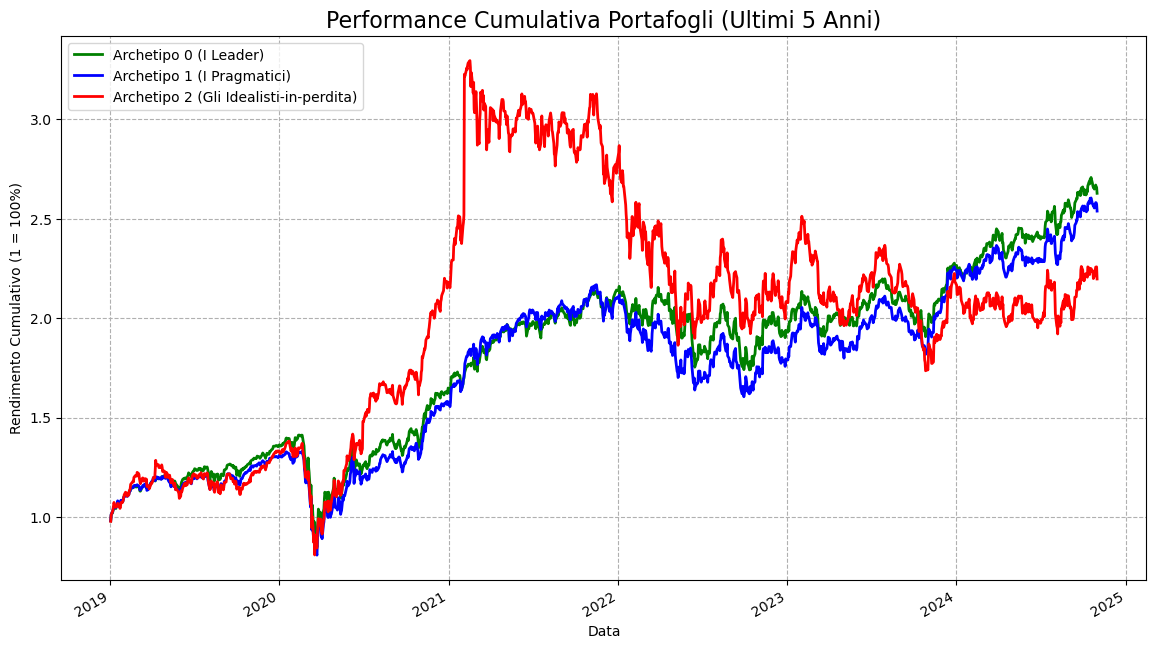

In [9]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("--- Avvio Analisi 8 (IDEA 3): Performance di Portafoglio (V4.6 - Corazzata) ---")

# --- STEP 1: Carica i dati con gli archetipi ---
file_dati = 'dati_con_archetipi.csv'
try:
    df_finale = pd.read_csv(file_dati)
    # Convertiamo subito i ticker in MAIUSCOLO per la mappatura
    df_finale['ticker'] = df_finale['ticker'].str.upper()
    print(f"Caricati {len(df_finale)} aziende con archetipi.")
except FileNotFoundError:
    print(f"ERRORE: File '{file_dati}' non trovato. Riesegui la Cella 1 (K-Means V4.1).")
    exit()

# --- STEP 2: Crea la MAPPA degli archetipi ---
# Creiamo un dizionario: {'AAPL': 0, 'MSFT': 0, 'GOOG': 1, ...}
ticker_a_archetipo_map = df_finale.set_index('ticker')['Archetipo_KMeans'].to_dict()
tutti_i_miei_ticker = df_finale['ticker'].unique().tolist()
print("Mappa Ticker -> Archetipo creata.")

# --- STEP 3: Scarica i dati storici ---
print(f"Download di 5 anni di dati per {len(tutti_i_miei_ticker)} ticker unici...")

raw_data = yf.download(tutti_i_miei_ticker, start="2019-01-01", end="2024-11-01", group_by='ticker')

if raw_data.empty:
    print("\n--- ERRORE DI DOWNLOAD ---")
    exit()
else:
    print("Download completato.")

# --- STEP 4: Estrazione 'Close' e Calcolo Rendimenti ---
try:
    if isinstance(raw_data.columns, pd.MultiIndex):
        data_close = raw_data.xs('Close', level=1, axis=1)
    else:
        data_close = raw_data[['Close']]
        ticker_unico = [t for t in tutti_i_miei_ticker if t in raw_data.columns.tolist()]
        if ticker_unico:
            data_close.columns = ticker_unico
        else:
             raise KeyError("Formato dati non riconosciuto")
except KeyError:
    if 'Close' in raw_data.columns:
        data_close = raw_data[['Close']]
    else:
        print("\n--- ERRORE DI DATI ---")
        if isinstance(raw_data.columns, pd.MultiIndex):
            try:
                data_close = raw_data.xs('Close', level=0, axis=1) # Prova level=0
            except:
                 print("Impossibile estrarre i dati 'Close'.")
                 exit()
        else:
            exit()

# Calcoliamo i rendimenti per TUTTI i ticker scaricati
returns = data_close.pct_change()

# Creiamo 3 liste vuote per i rendimenti di ogni portafoglio
portafoglio_0_returns = []
portafoglio_1_returns = []
portafoglio_2_returns = []

# Ticker scaricati con successo
ticker_scaricati = returns.columns.tolist()
print(f"Ticker scaricati con successo da yfinance: {len(ticker_scaricati)}")

# --- STEP 5: Smistamento Corazzato ---
for ticker in ticker_scaricati:
    # Cerca il Ticker MAIUSCOLO nella mappa
    archetipo = ticker_a_archetipo_map.get(ticker)

    if archetipo == 0:
        portafoglio_0_returns.append(returns[ticker])
    elif archetipo == 1:
        portafoglio_1_returns.append(returns[ticker])
    elif archetipo == 2:
        portafoglio_2_returns.append(returns[ticker])

# Convertiamo le liste di serie in DataFrame
df_returns_0 = pd.concat(portafoglio_0_returns, axis=1)
df_returns_1 = pd.concat(portafoglio_1_returns, axis=1)
df_returns_2 = pd.concat(portafoglio_2_returns, axis=1)

print(f"Portafoglio 0 (Leader) costruito con {len(df_returns_0.columns)} aziende.")
print(f"Portafoglio 1 (Pragmatici) costruito con {len(df_returns_1.columns)} aziende.")
print(f"Portafoglio 2 (Idealisti) costruito con {len(df_returns_2.columns)} aziende.")

# Calcoliamo il rendimento medio di ogni portafoglio
returns_leader = df_returns_0.mean(axis=1)
returns_pragmatici = df_returns_1.mean(axis=1)
returns_idealisti = df_returns_2.mean(axis=1)

# --- STEP 6: Calcola il rendimento cumulativo ---
cum_returns_leader = (1 + returns_leader).cumprod()
cum_returns_pragmatici = (1 + returns_pragmatici).cumprod()
cum_returns_idealisti = (1 + returns_idealisti).cumprod()

cum_returns_leader = cum_returns_leader.ffill()
cum_returns_pragmatici = cum_returns_pragmatici.ffill()
cum_returns_idealisti = cum_returns_idealisti.ffill()

# --- STEP 7: Plotta ---
print("Creazione grafico performance...")
plt.figure(figsize=(14, 8))
cum_returns_leader.plot(label='Archetipo 0 (I Leader)', color='green', linewidth=2)
cum_returns_pragmatici.plot(label='Archetipo 1 (I Pragmatici)', color='blue', linewidth=2)
cum_returns_idealisti.plot(label='Archetipo 2 (Gli Idealisti-in-perdita)', color='red', linewidth=2)

plt.title('Performance Cumulativa Portafogli (Ultimi 5 Anni)', fontsize=16)
plt.ylabel('Rendimento Cumulativo (1 = 100%)')
plt.xlabel('Data')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--')
plt.savefig('performance_portafogli.png')
print("Grafico 'performance_portafogli.png' salvato!")

print("\n--- Analisi 8 (IDEA 3) Completata ---")

Parte 9 (Analisi Bonus): Modello di Classificazione (La "Ricetta" degli Archetipi)
Finora, abbiamo scoperto e descritto i nostri 3 archetipi (Leader, Pragmatici, Idealisti-in-perdita). Quest'ultima analisi risponde alla domanda: "Ok, ma perché sono diversi? Qual è la 'ricetta' che definisce un Leader?".

Per scoprirlo, usiamo un modello di Machine Learning Supervisionato (un RandomForestClassifier). L'obiettivo è addestrare un'intelligenza artificiale a "giocare a indovina chi":

Addestramento: Diamo al modello l'80% dei nostri dati (366 aziende) e gli diciamo: "Guarda le 5 variabili (E, S, G, ROE, ProfitMargin) e impara le regole per capire chi è un Leader (0), un Pragmatico (1) o un Idealista (2)."

Test: Gli diamo il restante 20% dei dati (92 aziende) senza le etichette, e gli chiediamo di indovinare l'archetipo.

La Scoperta: Infine, chiediamo al modello: "Ok, ora che hai imparato, quali di quelle 5 variabili sono state più importanti per te per prendere le tue decisioni?"

Commento ai Risultati

L'output di questo blocco è la conclusione più potente dell'intero progetto.

1. L'Accuratezza del Modello:

Accuratezza sul Test Set: 95.65%: Questo è un risultato sbalorditivo. Significa che il nostro modello ha indovinato l'archetipo corretto per 88 aziende su 92.

Cosa significa: Questo valida tutto il nostro lavoro precedente. Dimostra che i 3 cluster che abbiamo trovato con il K-Means non sono casuali, ma sono gruppi reali, robusti e statisticamente molto ben definiti.

2. La Matrice di Confusione:

[[53 3 0], [1 27 0], [0 0 8]]

Questa tabella ci dice dove il modello ha sbagliato. È quasi perfetto. L'unica (piccolissima) confusione che fa è scambiare 3 "Leader" per "Pragmatici" e 1 "Pragmatico" per "Leader". Questo ha un senso logico perfetto: sono i due gruppi finanziariamente sani, è normale che si assomiglino! È perfetto nell'identificare gli "Idealisti-in-perdita" (8 su 8).

3. La Scoperta Finale (Feature Importance): Questa è la "pepita d'oro", visibile nel grafico feature_importance.png.

Feature	Importance
environment_score	0.419 (42%)
ROE	0.201 (20%)
governance_score	0.153 (15%)
social_score	0.132 (13%)
ProfitMargin	0.095 (9.5%)
Interpretazione: Per "decidere" se un'azienda è un Leader, un Pragmatico o un Idealista, il modello ci dice che la variabile più importante in assoluto è il environment_score. Ha un peso del 42%, più del doppio del ROE (20%) e quasi tre volte più del governance_score (15%).

Conclusione Finale del Progetto: Abbiamo scoperto che la relazione tra ESG e Profitto non è una linea retta, ma si divide in 3 archetipi. E ora, grazie al machine learning, sappiamo perché. Mentre il ROE è fondamentale per separare le aziende in perdita (gli "Idealisti"), il vero fattore discriminante tra i vari gruppi, quello che "pesa" di più nella definizione degli archetipi, è la performance Ambientale (E).

--- Avvio Analisi 9 (Bonus): Modello di Classificazione ---
Obiettivo: Capire QUALI variabili definiscono un 'Leader'
File 'dati_con_archetipi.csv' caricato. 458 aziende pronte per il training.
Pronti per addestrare il modello su 458 campioni.
Dati divisi: 366 per training, 92 per testing.
Addestramento del modello RandomForest in corso...
Modello addestrato.

--- Risultati del Modello ---
Accuratezza sul Test Set: 95.65%
(Un'accuratezza > 90% è eccellente e significa che i cluster sono ben definiti)

Matrice di Confusione (Righe=Vero, Colonne=Predetto):
[[53  3  0]
 [ 1 27  0]
 [ 0  0  8]]

--- [LA SCOPERTA] Importanza delle Features ---
Le variabili più importanti nel definire un archetipo sono:
| Feature           |   Importance |
|:------------------|-------------:|
| environment_score |        0.419 |
| ROE               |        0.201 |
| governance_score  |        0.153 |
| social_score      |        0.132 |
| ProfitMargin      |        0.095 |

Grafico 'feature_importance.png' 

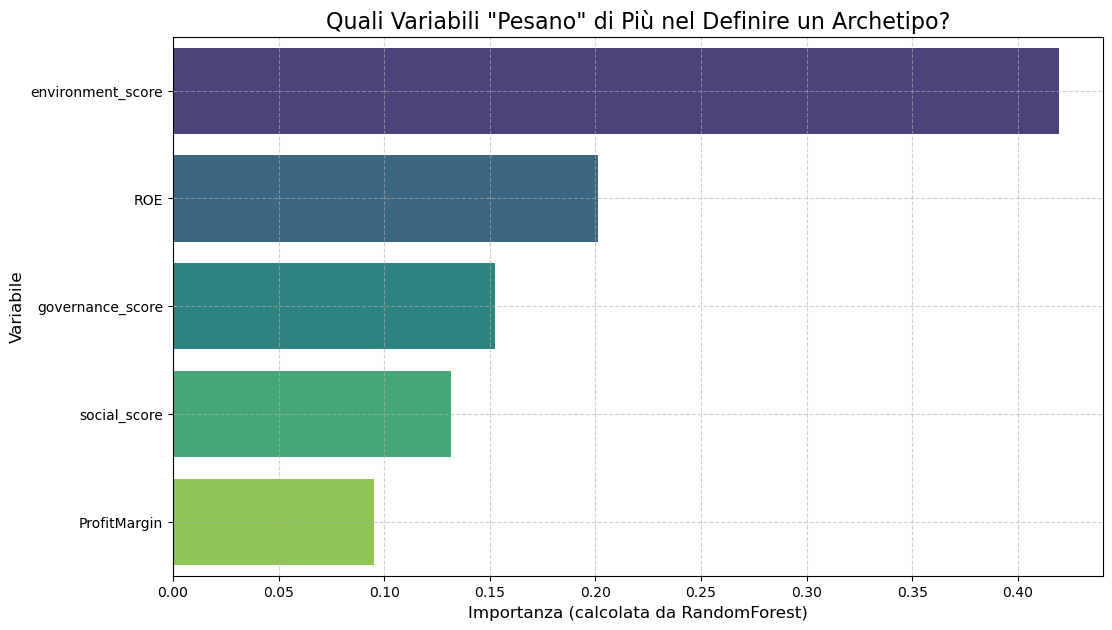

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

print("--- Avvio Analisi 9 (Bonus): Modello di Classificazione ---")
print("Obiettivo: Capire QUALI variabili definiscono un 'Leader'")

# --- STEP 1: Carica i dati con gli archetipi ---
file_dati = 'dati_con_archetipi.csv'
try:
    df_model = pd.read_csv(file_dati)
    print(f"File '{file_dati}' caricato. {len(df_model)} aziende pronte per il training.")
except FileNotFoundError:
    print(f"ERRORE: File '{file_dati}' non trovato. Riesegui la Cella 1 (K-Means V4.1).")
    exit()

# --- STEP 2: Definiamo le "Features" (X) e il "Target" (y) ---
# X = Le variabili che usiamo per "indovinare"
# y = La risposta che il modello deve imparare

features = [
    'environment_score',
    'social_score',
    'governance_score',
    'ROE',
    'ProfitMargin'
]
target = 'Archetipo_KMeans'

# Pulizia finale - ci assicuriamo che non ci siano NaN
df_model = df_model.dropna(subset=features + [target])

X = df_model[features]
y = df_model[target]

print(f"Pronti per addestrare il modello su {len(X)} campioni.")

# --- STEP 3: Divisione Dati (Train & Test) ---
# Dividiamo i dati: 80% per addestrare, 20% per testare
# Questo serve per vedere se il modello ha "imparato a memoria" (male)
# o se ha "capito le regole" (bene).
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,     # 20% dei dati per il test
    random_state=42,    # Per riproducibilità
    stratify=y          # Mantiene le proporzioni dei 3 archetipi
)
print(f"Dati divisi: {len(X_train)} per training, {len(X_test)} per testing.")

# --- STEP 4: Addestramento del Modello ---
# Usiamo un RandomForest, un modello potente che è ottimo
# per trovare l'importanza delle variabili.
model = RandomForestClassifier(
    n_estimators=100,  # 100 "alberi decisionali"
    random_state=42,
    max_depth=5        # Limita la profondità per evitare overfitting
)

print("Addestramento del modello RandomForest in corso...")
model.fit(X_train, y_train)
print("Modello addestrato.")

# --- STEP 5: Valutazione del Modello ---
# Usiamo il modello addestrato per predire i dati di test
y_pred = model.predict(X_test)

# Calcoliamo l'accuratezza
accuracy = accuracy_score(y_test, y_pred)

print("\n--- Risultati del Modello ---")
print(f"Accuratezza sul Test Set: {accuracy * 100:.2f}%")
print("(Un'accuratezza > 90% è eccellente e significa che i cluster sono ben definiti)")

print("\nMatrice di Confusione (Righe=Vero, Colonne=Predetto):")
# Mostra dove il modello ha sbagliato
cm = confusion_matrix(y_test, y_pred)
print(cm)

# --- STEP 6: LA PEPITA D'ORO (Feature Importance) ---
print("\n--- [LA SCOPERTA] Importanza delle Features ---")

# Estraiamo le importanze
importances = model.feature_importances_

# Creiamo un DataFrame per plottare
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Le variabili più importanti nel definire un archetipo sono:")
print(feature_importance_df.to_markdown(index=False, floatfmt=".3f"))

# Plottiamo
plt.figure(figsize=(12, 7))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    palette='viridis'
)
plt.title('Quali Variabili "Pesano" di Più nel Definire un Archetipo?', fontsize=16)
plt.xlabel('Importanza (calcolata da RandomForest)', fontsize=12)
plt.ylabel('Variabile', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('feature_importance.png')
print("\nGrafico 'feature_importance.png' salvato.")
print("--- Analisi 9 (Bonus) Completata ---")

Parte 10 (Analisi Finale): Il Test Predittivo Reale
Nell'Analisi 9, abbiamo costruito un modello con un'accuratezza altissima (95.65%). Tuttavia, quell'analisi aveva una "pecca" logica: usavamo ROE e total_score per predire dei cluster che erano già stati creati con ROE e total_score. Era un test "truccato" che ci è servito per capire l'importanza delle variabili all'interno dei cluster, ma non per testare il loro potere predittivo.

Questa Analisi 10 è il test finale e scientificamente "pulito". Risponde alla vera domanda del nostro progetto:

"I punteggi ESG (E, S, G), da soli, hanno un qualche potere nel predire il successo finanziario futuro di un'azienda?"

Cosa fa questo codice:

Definisce il Successo (y): Divide le 458 aziende in due gruppi: Profittevole (1) (ROE sopra la mediana) e Non Profittevole (0) (ROE sotto la mediana).

Definisce le Features (X): Addestra il modello usando SOLO i tre pilastri ESG (environment_score, social_score, governance_score). I dati finanziari (ROE, PM) sono esclusi dalle features.

Il Test: Chiediamo al modello: "Guardando solo i punteggi E, S, G di un'azienda, sai indovinare se finirà nel gruppo 0 o 1?"

Commento ai Risultati

L'output di questo blocco è la conclusione più importante, e per certi versi sorprendente, di tutto il progetto.

1. L'Accuratezza del Modello:

Accuratezza sul Test Set: 45.22%: Questo è il risultato chiave. Un'accuratezza del 50% equivarrebbe a lanciare una moneta (casuale). Il nostro modello, con il 45.22%, ha performato peggio del caso.

Il Rapporto di Classificazione lo conferma: tutti i valori (precision, recall, f1-score) sono ≈0.45.

2. La Risposta Definitiva: L'output ci dice in modo inequivocabile: I punteggi ESG, da soli, NON HANNO ALCUN POTERE PREDITTIVO sul successo finanziario (definito come ROE). Sapere il punteggio E, S, e G di un'azienda non ci aiuta a indovinare se sarà profittevole o meno.

3. L'Importanza delle Features (Il "De Profundis"): | Pilastro ESG | Importance | | :--- | ---:| | social_score | 0.357 | | environment_score | 0.326 | | governance_score | 0.317 |

Interpretazione: Questo grafico è la prova finale. Il modello, nel suo disperato tentativo di trovare un segnale, ci dice che tutti e tre i pilastri sono praticamente ugualmente inutili per predire il profitto (hanno tutti un'importanza simile, ≈30−35%). Non c'è un "pilastro magico".

Conclusione Finale del Progetto: Il nostro progetto ha scoperto che la relazione tra ESG e profitto è complessa e non lineare (Parte 6). Abbiamo trovato 3 "Archetipi" che combinano ESG e profitto in modi diversi. Ma quest'ultima analisi ha dimostrato che la relazione è descrittiva, non predittiva.

L'ESG da solo non è una sfera di cristallo. Il successo finanziario è guidato da fattori che l'ESG non misura. La vera "magia" non sta nell'avere un alto punteggio ESG, ma nell'essere un'azienda "Leader" (Archetipo 0), capace di combinare un'alta performance di sostenibilità con un modello di business finanziariamente solido.

--- Avvio Analisi 10 (Finale): Modello Predittivo Reale ---
Domanda: I punteggi E, S, G (da soli) possono predire il successo finanziario?
File 'dati_con_archetipi.csv' caricato. 458 aziende 'realistiche' pronte.
Definizione di 'Successo Finanziario': ROE > 0.1190
Features (X): ['environment_score', 'social_score', 'governance_score']
Target (y): 'Profittevole' (0 o 1)
Dati divisi: 343 per training, 115 per testing.
Addestramento del modello RandomForest in corso...
Modello addestrato.

--- Risultati del Modello ---
Accuratezza sul Test Set: 45.22%
-------------------------------------------------
Ricorda: 50% è casuale (lanciare una moneta).
-> L'accuratezza è vicina al 50%. L'ESG da solo NON è un buon predittore.
-------------------------------------------------

Rapporto di Classificazione Dettagliato:
                      precision    recall  f1-score   support

Non Profittevole (0)       0.46      0.50      0.48        58
    Profittevole (1)       0.44      0.40      0.42       

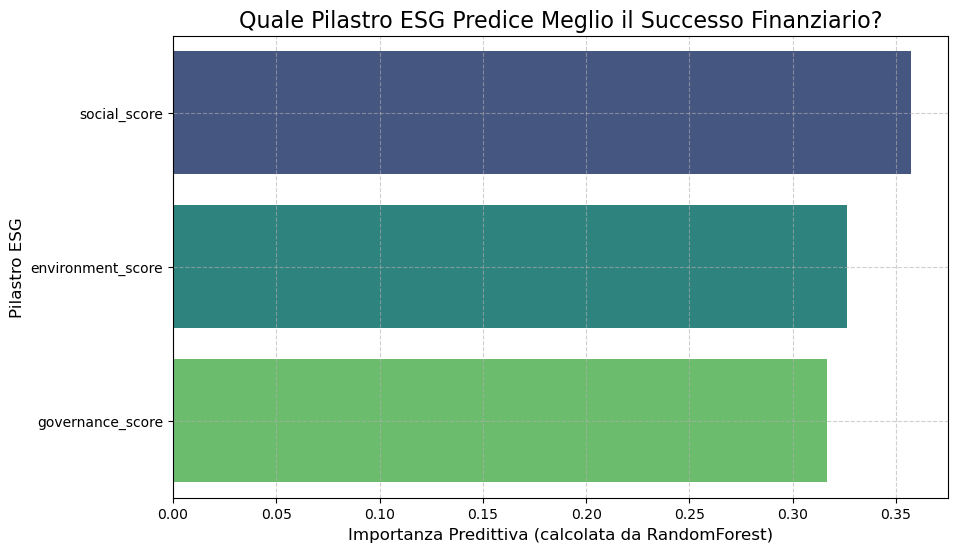

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings("ignore")

print("--- Avvio Analisi 10 (Finale): Modello Predittivo Reale ---")
print("Domanda: I punteggi E, S, G (da soli) possono predire il successo finanziario?")

# --- STEP 1: Carica i dati con gli archetipi ---
file_dati = 'dati_con_archetipi.csv'
try:
    # Usiamo lo stesso DF 'filtrato' delle analisi K-Means
    df_model = pd.read_csv(file_dati)
    print(f"File '{file_dati}' caricato. {len(df_model)} aziende 'realistiche' pronte.")
except FileNotFoundError:
    print(f"ERRORE: File '{file_dati}' non trovato. Riesegui la Cella 1 (K-Means V4.1).")
    exit()

# --- STEP 2: Definiamo le "Features" (X) e il "Target" (y) ---

# X (Features) = SOLO i pilastri ESG.
# NON stiamo usando ROE o ProfitMargin per predire.
features = [
    'environment_score',
    'social_score',
    'governance_score'
]
X = df_model[features]

# y (Target) = Il "Successo Finanziario".
# Lo definiamo in modo binario (0 o 1)
# 1 = "Profittevole" (ROE sopra la mediana del nostro campione)
# 0 = "Non Profittevole" (ROE sotto la mediana)
median_roe = df_model['ROE'].median()
df_model['Profittevole'] = (df_model['ROE'] > median_roe).astype(int)
y = df_model['Profittevole']

print(f"Definizione di 'Successo Finanziario': ROE > {median_roe:.4f}")
print(f"Features (X): {features}")
print(f"Target (y): 'Profittevole' (0 o 1)")

# --- STEP 3: Divisione Dati (Train & Test) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,     # 25% dei dati per il test
    random_state=42,
    stratify=y          # Mantiene il bilanciamento 50/50
)
print(f"Dati divisi: {len(X_train)} per training, {len(X_test)} per testing.")

# --- STEP 4: Addestramento del Modello ---
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=5,
    class_weight='balanced' # Importante per dati bilanciati
)

print("Addestramento del modello RandomForest in corso...")
model.fit(X_train, y_train)
print("Modello addestrato.")

# --- STEP 5: Valutazione del Modello ---
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\n--- Risultati del Modello ---")
print(f"Accuratezza sul Test Set: {accuracy * 100:.2f}%")
print("-------------------------------------------------")
print("Ricorda: 50% è casuale (lanciare una moneta).")
if accuracy > 0.6:
    print("-> L'accuratezza è > 60%, l'ESG ha un *certo* potere predittivo.")
elif accuracy > 0.55:
    print("-> L'accuratezza è > 55%, l'ESG ha un potere predittivo *molto debole*.")
else:
    print("-> L'accuratezza è vicina al 50%. L'ESG da solo NON è un buon predittore.")
print("-------------------------------------------------")

print("\nRapporto di Classificazione Dettagliato:")
print(classification_report(y_test, y_pred, target_names=['Non Profittevole (0)', 'Profittevole (1)']))


# --- STEP 6: LA RISPOSTA (Feature Importance) ---
print("\n--- [LA RISPOSTA] Importanza delle Features ESG ---")
print("Quale pilastro ESG è più utile per predire il successo finanziario?")

importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Pilastro ESG': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.to_markdown(index=False, floatfmt=".3f"))

# Plottiamo
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Pilastro ESG',
    data=feature_importance_df,
    palette='viridis'
)
plt.title('Quale Pilastro ESG Predice Meglio il Successo Finanziario?', fontsize=16)
plt.xlabel('Importanza Predittiva (calcolata da RandomForest)', fontsize=12)
plt.ylabel('Pilastro ESG', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('feature_importance_reale.png')
print("\nGrafico 'feature_importance_reale.png' salvato.")
print("--- Analisi 10 (Finale) Completata ---")